In [3]:
import math
import csv
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

from time import sleep
from collections import deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from importnb import Notebook
with Notebook():
    from LabLatencyModel import LatencyModel, MultiDULatencyModel
    from LabCacheEngine import CacheEngineEnv
    from LabUserTileRequest import UserTileRequestEvents
    from LabEnvWrapper import EnvWrapper

import sys
# sys.path.append(r'c:\Users\es25591\Workspace\CacheVideoPredict360\Sources')
sys.path.append('/home/eduardo/Workspace/CacheVideoPredict360/Sources')
from Common.Utils import save_training_results



In [28]:
# Check PyTorch GPU availability and basic operation
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Using device: {torch.cuda.get_device_name(torch.cuda.current_device())}")
    x = torch.randn(2, 2, device="cuda")
    y = torch.randn(2, 2, device="cuda")
    print("Sample CUDA tensor sum:\n", (x + y))
else:
    print("GPU not detected; running on CPU.")

CUDA available: True
Using device: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Sample CUDA tensor sum:
 tensor([[ 0.8197, -1.2516],
        [-1.3570,  0.0649]], device='cuda:0')


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        # state shape: (seq_len, input_size)
        self.memory.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class LSTM_DQN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(LSTM_DQN, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM Layer: Takes sequence of viewports
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully Connected Layer: Maps LSTM output to Q-values (one per tile index)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden=None):
        # x shape: (batch, seq_len, input_size)
        
        # LSTM output shape: (batch, seq_len, hidden_size)
        lstm_out, hidden = self.lstm(x, hidden)
        
        # We only care about the output of the last time step for prediction
        last_time_step = lstm_out[:, -1, :]
        
        # Q-values
        q_values = self.fc(last_time_step)
        return q_values, hidden

class DQNAgent:
    def __init__(
        self, 
        n_tiles, 
        seq_len, 
        learning_rate=1e-3, 
        gamma=0.99,
        batch_size=64,
        capacity=10000,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.995
    ):
        self.n_tiles = n_tiles
        self.seq_len = seq_len
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        
        self.policy_net = LSTM_DQN(n_tiles, 32, n_tiles).to(device)
        self.target_net = LSTM_DQN(n_tiles, 32, n_tiles).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(
            self.policy_net.parameters(), 
            lr=learning_rate
        )

        self.criterion = nn.MSELoss()
        self.memory = ReplayMemory(capacity=capacity)
        self.batch_size = batch_size

    def select_action(self, state_seq):
        """
        state_seq: numpy array of shape (seq_len, n_tiles)
        Returns: integer index of the predicted center tile
        """
        if random.random() < self.epsilon:
            return random.randrange(self.n_tiles), None
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state_seq).unsqueeze(0).to(device)
                q_values, _ = self.policy_net(state_tensor)
                return q_values.argmax().item(), q_values.cpu().numpy()

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return 0.0
        
        batch = self.memory.sample(self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert to tensors
        states = torch.FloatTensor(np.array(states)).to(device)      # (B, Seq, Input)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)  # (B, 1)
        rewards = torch.FloatTensor(rewards).to(device)
        dones = torch.FloatTensor(np.array(dones, dtype=np.float32)).to(device)

        # Compute Q(s, a)
        q_values, _ = self.policy_net(states)
        state_action_values = q_values.gather(1, actions).squeeze(1)

        # Compute V(s')
        with torch.no_grad():
            next_q_values, _ = self.target_net(next_states)
            next_state_values = next_q_values.max(1)[0]
            expected_state_action_values = rewards + (self.gamma * next_state_values * (1 - dones))

        # Loss and Optimize
        loss = self.criterion(state_action_values, expected_state_action_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        return loss.item()

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

In [30]:
def index_to_fov_mask(center_idx, n):
    """
    Converts a predicted center tile index into a binary mask of neighbors.
    Simulates a 3x3 (or specific FOV) grid around the center.
    """
    mask = np.zeros(n*n, dtype=int)
    
    # Grid coordinates
    cy, cx = divmod(center_idx, n)
    
    # Define a simple FOV range (e.g., center + immediate neighbors)
    # Adjust range to match the desired viewport size (roughly 90 deg)
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            ny, nx = cy + dy, cx + dx
            if 0 <= ny < n and 0 <= nx < n:
                mask[ny * n + nx] = 1
                
    return mask

In [31]:
if __name__ == "__main__":
    n_episodes = 200
    n_nodes = 10
    n_users = 100
    step_size = 5.0
    arrival_rate = 10.0  # users per second
    alpha = 2.0
    n_videos = 100
    n_gops = 60
    n_layers = 2
    n = 4
    n_tiles = n * n
    max_capacity = 500e6  # 500 MB

    # Hyperparameters for RL
    epsilon_start = 1.0
    epsilon_min = 0.05
    epsilon_decay = 0.985
    gamma = 0.99
    learning_rate = 1e-3
    batch_size = 64
    capacity = 10000
    window_len = 5  # LSTM sequence length (history window)

    # CPT parameters
    theta = 0.5
    lam = 3.7183

    # du_caches = [
    #     CacheEngineEnv(
    #         n_users=n_users,
    #         n_videos=n_videos,
    #         n_layers=n_layers,
    #         n_tiles=n_tiles,
    #         n_gops=n_gops,
    #         cache_capacity=max_capacity,
    #     ) for _ in range(n_nodes)
    # ]
    du_caches = []

    mec_cache = CacheEngineEnv(
        n_users=n_users,
        n_videos=n_videos,
        n_layers=n_layers,
        n_tiles=n_tiles,
        n_gops=n_gops,
        cache_capacity=max_capacity,
    )

    # Initialize User Environment
    users_env = UserTileRequestEvents(
        n_nodes=n_nodes,
        n_users=n_users,
        n_videos=n_videos,
        n_gops=n_gops,
        n_layers=n_layers,
        n_tiles=n_tiles,
        n=n,
        users_viewport_tiles=None,
        requested_videos=None,
        users_arrivals=None,
        arrival_rate=arrival_rate
    )

    # Create latency model (replace numbers with your real config)
    P = n_nodes; max_U = n_users
    lat_model = MultiDULatencyModel(
        P=P, 
        max_U=max_U,
        R_M_D=80e6,   # 640 Mbps -> 80e6 B/s
        R_C_M=125e6, # 1 Gbps -> 125e6 B/s
        mu=2e7, 
        eta=2e5,
        B_pu_matrix=np.full((P, max_U), 40e6, dtype=float),    # 320 Mbps -> 40e6 B/s
        gamma_pu_matrix=np.full((P, max_U), 5.0, dtype=float), # SNRs
        rhoT_p=[0.2], 
        lambda_p=[0.05],
        du_fixed_delay=0.001,    # 1 ms
        mec_fixed_delay=0.005,   # 5 ms
        cloud_fixed_delay=0.1   # 100 ms
    )

    env = EnvWrapper(
        n=n,
        n_layers=n_layers,
        users_env=users_env, 
        du_caches=du_caches,
        mec_cache=mec_cache,
        latency_model=lat_model,
        theta=theta,
        lam=lam
    )

    print(
        f"Experiment ===================\n"
        f"Total users: {n_users}\n"
        f"Cache capacity: {max_capacity}MB\n"
        f"Video matrix: {n_videos}x{n_layers}x{n*n}\n"
        f"==============================\n"
    )

    agent = DQNAgent(
        n_tiles=n_tiles, 
        seq_len=window_len,
        learning_rate=learning_rate,
        gamma=gamma,
        batch_size=batch_size,
        capacity=capacity,
        epsilon_start=epsilon_start,
        epsilon_min=epsilon_min,
        epsilon_decay=epsilon_decay
    )

    results = []
    scores = []
    active_users_log = []  # Track active users per step

    for ep in range(n_episodes):

        obs, info = env.reset()

        user_histories = {
            u: deque(
                [np.zeros(n*n) for _ in range(window_len)], maxlen=window_len
            ) for u in range(n_users)
        }

        cache_hits = 0
        cache_misses = 0
        enhanced_layer_cache_hits = 0
        enhanced_layer_cache_misses = 0
        base_layer_cache_hits = 0
        base_layer_cache_misses = 0
        total_reward = 0.0
        avg_psnr = []

        for step in count():

            # --- AGENT ACTIONS ---
            reqs_state = info['users_requests']
            active_users = [
                (req['u'], req['video'], req['gop']) 
                for req in reqs_state if req['gop'] < n_gops
            ]

            actions = []
            user_action_indices = {}

            for u, video, gop in active_users:
                cur_state_seq = np.array(user_histories[u])

                # Agent chooses center tile
                center_tile_idx, q_values = agent.select_action(cur_state_seq)
                user_action_indices[u] = center_tile_idx

                # Convert center tile to mask for the Env
                predicted_viewport = index_to_fov_mask(center_idx=center_tile_idx, n=n)

                actions.append({
                    'user': u,
                    'gop': gop,
                    'video': video,
                    'tiles': predicted_viewport
                })

            # --- STEP ENV ---
            obs, rewards, done, info = env.step(actions)

            total_reward += float(rewards)
            enhanced_layer_cache_hits += info["enh_layer_cache_hits"]
            enhanced_layer_cache_misses += info["enh_layer_cache_misses"]
            base_layer_cache_hits += info["base_layer_cache_hits"]
            base_layer_cache_misses += info["base_layer_cache_misses"]
            avg_psnr.append(info.get("average_psnr", 0.0))

            step_reward = float(rewards) / max(1, len(active_users))

            # --- TRAINING / HISTORY UPDATE ---
            reqs_next_state = info['users_requests']

            for u, video, gop in active_users:
                state_seq = np.array(user_histories[u])

                actual_viewport = np.zeros(n*n)
                target_indices = [
                    tile['tile'] 
                    for req in reqs_next_state 
                    if req['u'] == u 
                    for tile in req['tiles'] 
                    if tile['layer'] == 1
                ]
                actual_viewport[target_indices] = 1
                
                user_histories[u].append(actual_viewport)
                next_state_seq = np.array(user_histories[u])
                
                dones = (gop == n_gops)
                agent.memory.push(
                    state_seq,
                    user_action_indices[u], 
                    step_reward, 
                    next_state_seq, 
                    dones
                )
            
            agent.train_step()
            
            # print(f"Step {step}, Active Users: {len(active_users)}")
            # print(f"Request State: {reqs_state}")
            # print(f"Action: {actions}")
            # print(f"Next Request State: {reqs_next_state}")
            # print(
            #     f"Reward: {rewards}, "
            #     f"Cache Hits: {enhanced_layer_cache_hits + base_layer_cache_hits}, "
            #     f"Cache Misses: {enhanced_layer_cache_misses + base_layer_cache_misses}"
            # )
            # print("-----")
            
            if done:
                break

        # Update Target Network and Decay Epsilon
        if ep % 5 == 0:
            agent.update_target_network()

        agent.update_epsilon()

        avg_psnr = [x for x in avg_psnr if x != 0.0]

        cache_hits = enhanced_layer_cache_hits + base_layer_cache_hits
        cache_misses = enhanced_layer_cache_misses + base_layer_cache_misses

        print(
            f"Episode {ep+1}/{n_episodes}, "
            f"Total Reward: {total_reward:.4f}, "
            f"cache_hits: {cache_hits}, "
            f"cache_misses: {cache_misses}, "
            f"enh_layer_cache_hits: {enhanced_layer_cache_hits}, "
            f"enh_layer_cache_misses: {enhanced_layer_cache_misses}, "
            f"base_layer_cache_hits: {base_layer_cache_hits}, "
            f"base_layer_cache_misses: {base_layer_cache_misses}, "
            f"Average PSNR: {np.mean(avg_psnr) if avg_psnr else 0.0:.2f}, "
            f"Epsilon: {agent.epsilon:.4f}"
        )

        filename = (
            f"fov_predictor_"
            f"U{n_users}_V{n_videos}_G{n_gops}_L{n_layers}_N{n}_"
            f"cap{int(max_capacity/1e6)}MB_AR{arrival_rate}.csv"
        )

        save_training_results(
            path_='/home/eduardo/Workspace/CacheVideoPredict360/Results',
            # path_=r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results',
            filename=filename,
            ep=ep,
            total_reward=total_reward,
            cache_hits=cache_hits,
            cache_misses=cache_misses,
            enhanced_layer_cache_hits=enhanced_layer_cache_hits,
            enhanced_layer_cache_misses=enhanced_layer_cache_misses,
            base_layer_cache_hits=base_layer_cache_hits,
            base_layer_cache_misses=base_layer_cache_misses,
            avg_psnr=np.mean(avg_psnr) if avg_psnr else 0.0,
            agent=agent
        )

        scores.append(total_reward)

        results.append({
            "episode": ep,
            "total_reward": total_reward,
            "cache_hits": cache_hits,
            "cache_misses": cache_misses,
        })


Experiment ===================
Total users: 100
Cache capacity: 500000000.0MB
Video matrix: 100x2x16

Episode 1/200, Total Reward: 7291.2918, cache_hits: 109036, cache_misses: 11826, enh_layer_cache_hits: 13036, enh_layer_cache_misses: 11826, base_layer_cache_hits: 96000, base_layer_cache_misses: 0, Average PSNR: 38.00, Epsilon: 0.9850
Episode 2/200, Total Reward: 7538.0632, cache_hits: 109421, cache_misses: 11256, enh_layer_cache_hits: 13421, enh_layer_cache_misses: 11256, base_layer_cache_hits: 96000, base_layer_cache_misses: 0, Average PSNR: 38.16, Epsilon: 0.9702
Episode 3/200, Total Reward: 7247.2924, cache_hits: 109249, cache_misses: 11626, enh_layer_cache_hits: 13249, enh_layer_cache_misses: 11626, base_layer_cache_hits: 96000, base_layer_cache_misses: 0, Average PSNR: 38.14, Epsilon: 0.9557
Episode 4/200, Total Reward: 7949.4262, cache_hits: 109969, cache_misses: 10819, enh_layer_cache_hits: 13969, enh_layer_cache_misses: 10819, base_layer_cache_hits: 96000, base_layer_cache_mi

/tmp/ipykernel_296811/3657158268.py:17: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[0].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
/tmp/ipykernel_296811/3657158268.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[1].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
/tmp/ipykernel_296811/3657158268.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[2].set_ylim(bottom=0)


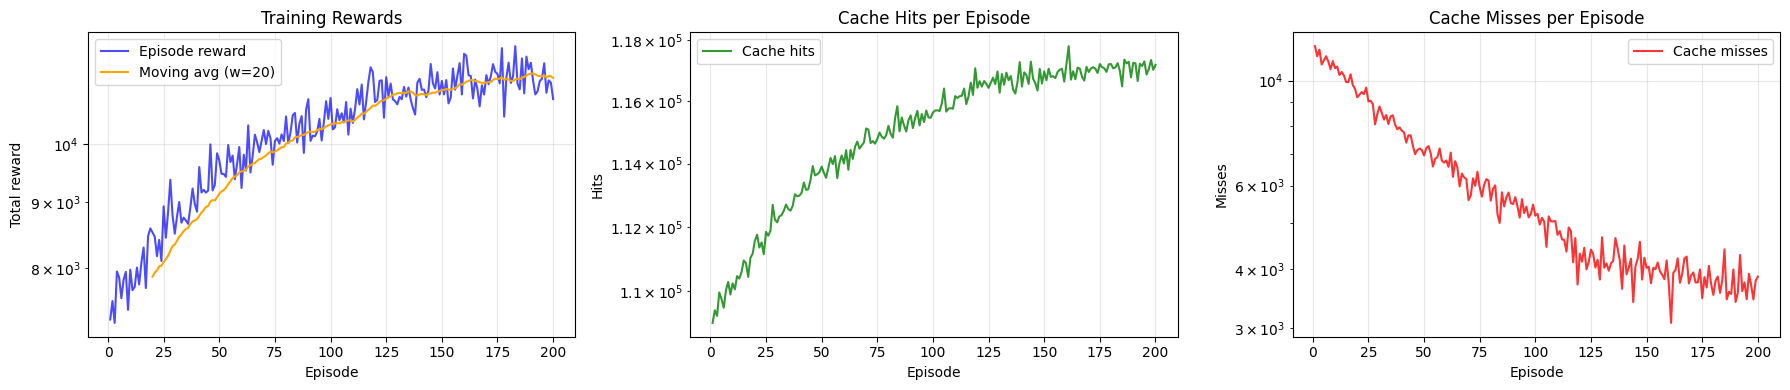

In [32]:
episodes = range(1, len(scores) + 1)
cache_hits_series = [r["cache_hits"] for r in results]
cache_misses_series = [r["cache_misses"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

# 1. Rewards with moving average
axes[0].plot(episodes, scores, label="Episode reward", alpha=0.7, color="blue")
w = max(1, min(20, len(scores) // 10))
if w > 1:
    ma = [sum(scores[i - w:i]) / w for i in range(w, len(scores) + 1)]
    axes[0].plot(range(w, len(scores) + 1), ma, label=f"Moving avg (w={w})", color="orange")
axes[0].set_yscale('log') 
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")
axes[0].set_title("Training Rewards")
axes[0].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2. Cache hits
axes[1].plot(episodes, cache_hits_series, label="Cache hits", color="green", alpha=0.8)
axes[1].set_yscale('log') 
axes[1].set_title("Cache Hits per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Hits")
axes[1].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# 3. Cache misses
axes[2].plot(episodes, cache_misses_series, label="Cache misses", color="red", alpha=0.8)
axes[2].set_yscale('log')
axes[2].set_title("Cache Misses per Episode")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Misses")
axes[2].set_ylim(bottom=0)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

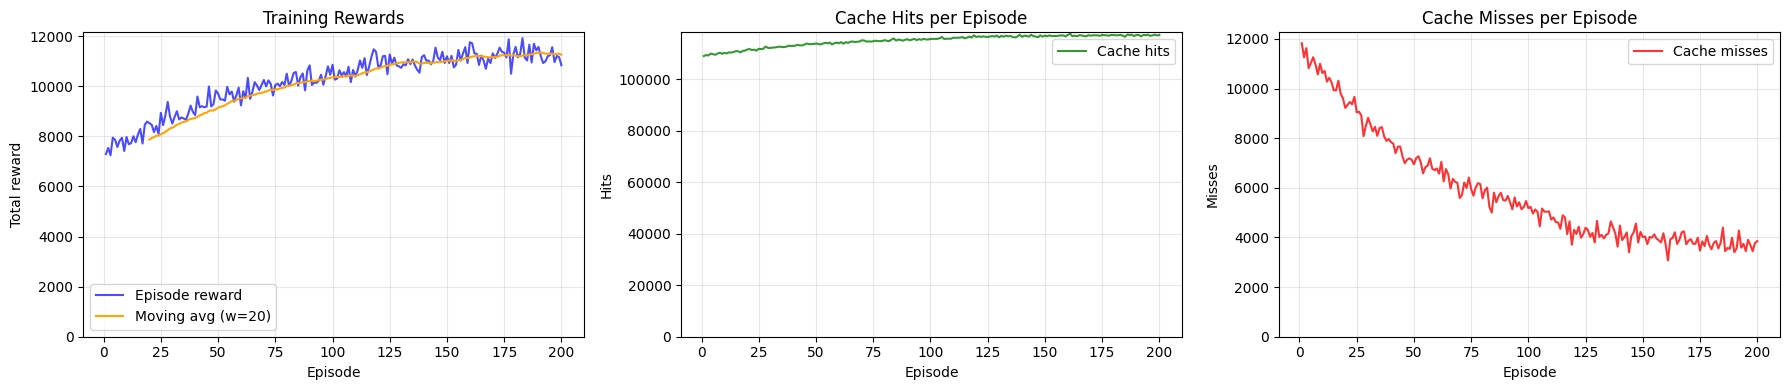

In [33]:
episodes = range(1, len(scores) + 1)
cache_hits_series = [r["cache_hits"] for r in results]
cache_misses_series = [r["cache_misses"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

# Rewards with moving average
axes[0].plot(episodes, scores, label="Episode reward", alpha=0.7, color="blue")
w = max(1, min(20, len(scores) // 10))
if w > 1:
    ma = [sum(scores[i - w:i]) / w for i in range(w, len(scores) + 1)]
    axes[0].plot(range(w, len(scores) + 1), ma, label=f"Moving avg (w={w})", color="orange")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")
axes[0].set_title("Training Rewards")
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Cache hits
axes[1].plot(episodes, cache_hits_series, label="Cache hits", color="green", alpha=0.8)
axes[1].set_title("Cache Hits per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Hits")
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Cache misses
axes[2].plot(episodes, cache_misses_series, label="Cache misses", color="red", alpha=0.8)
axes[2].set_title("Cache Misses per Episode")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Misses")
axes[2].set_ylim(bottom=0)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

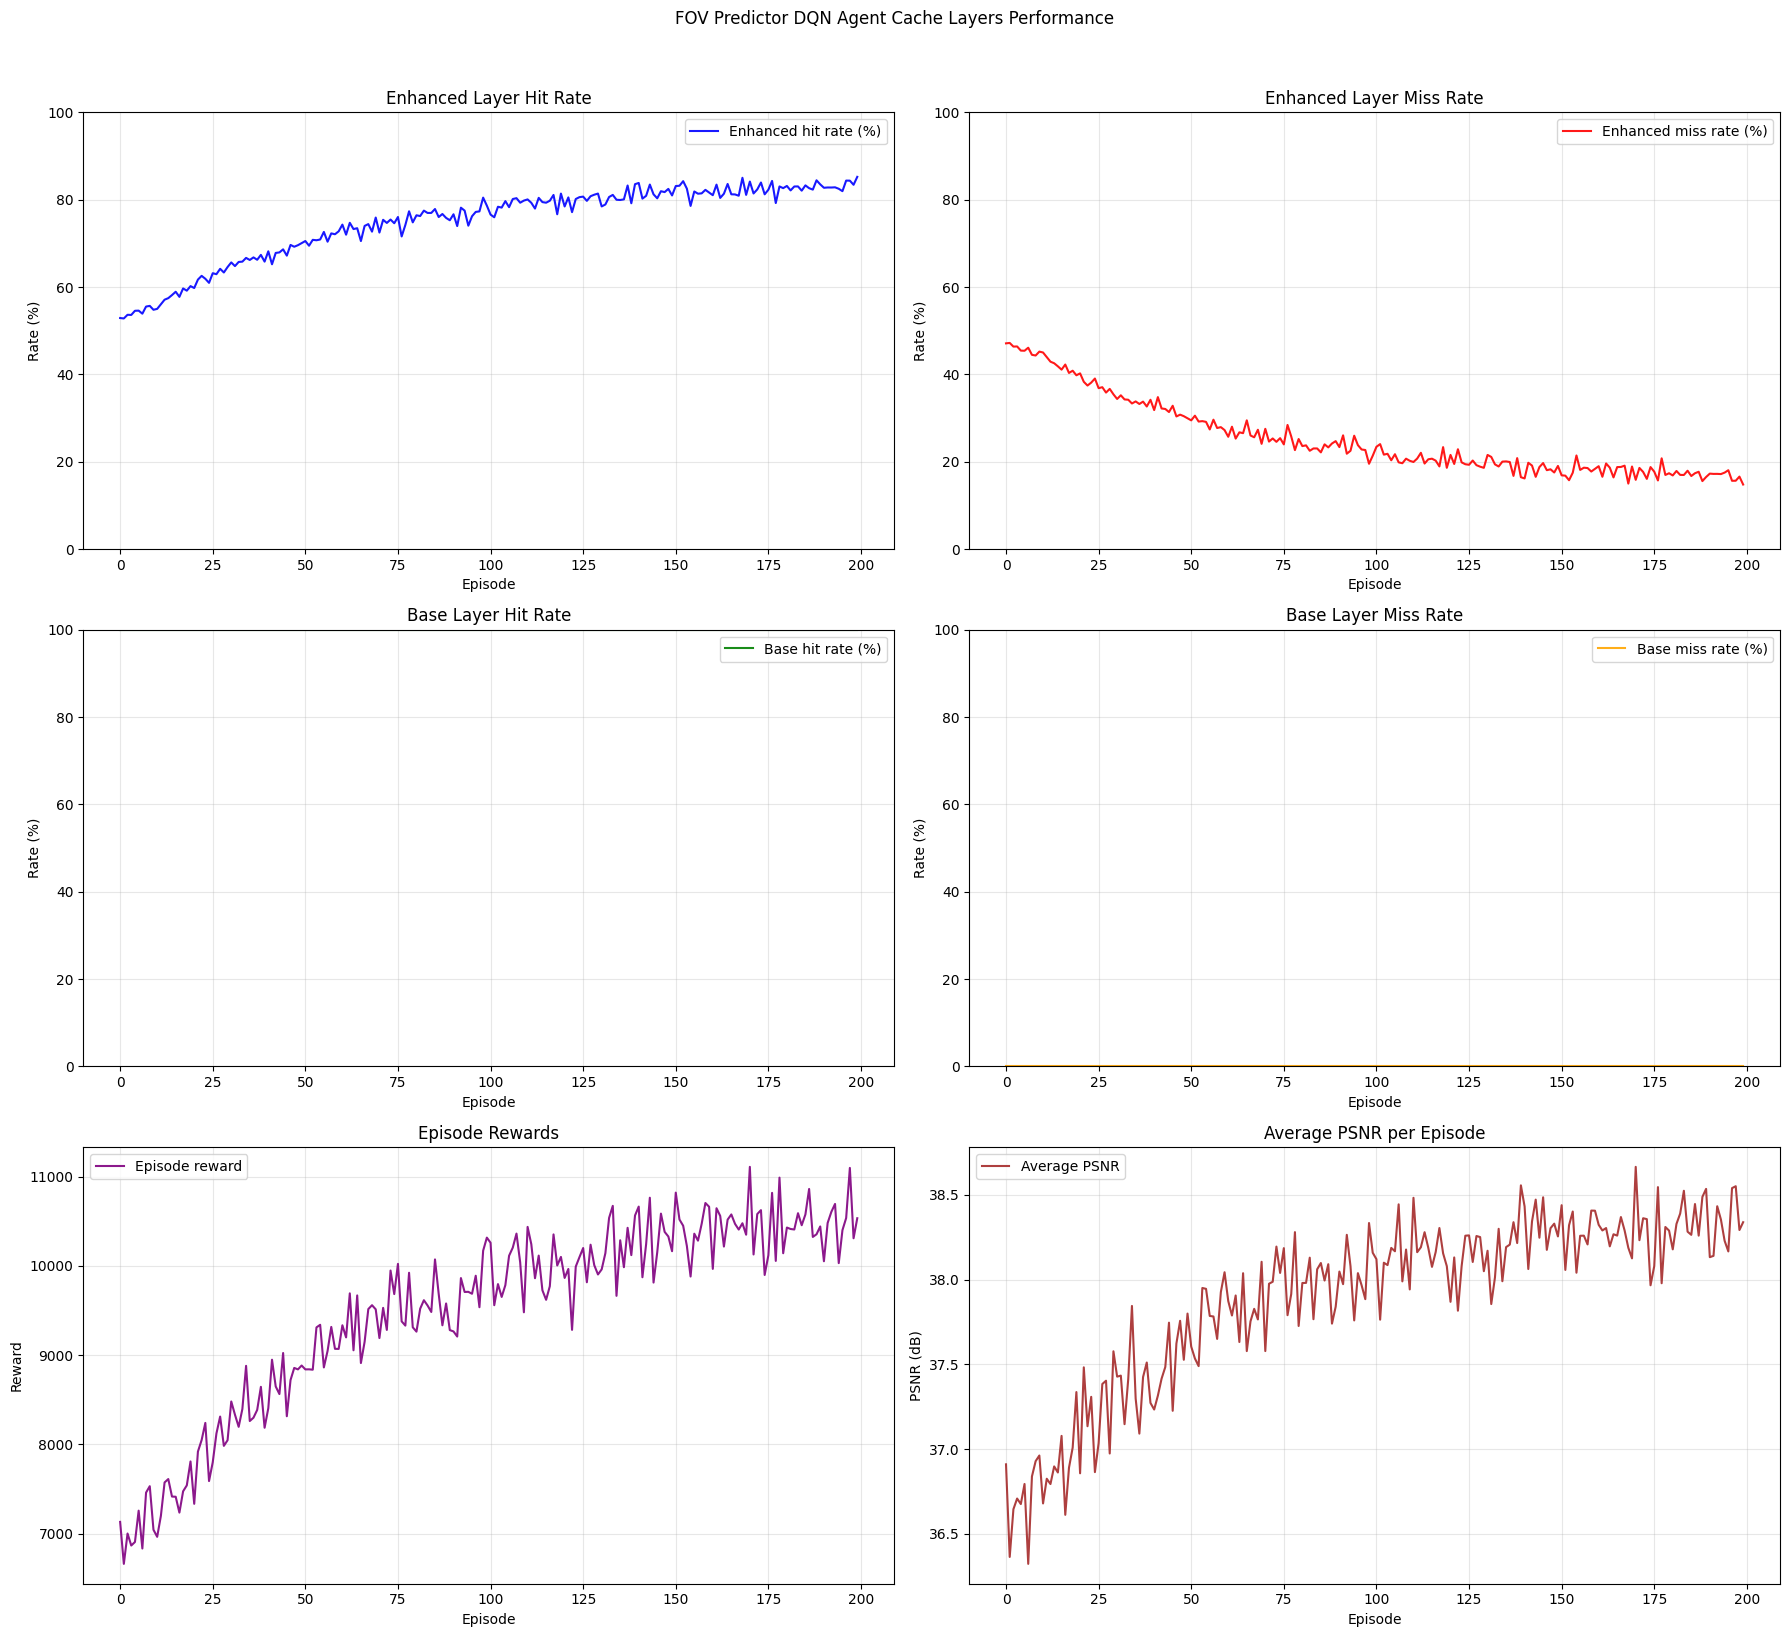

In [15]:
from typing import List
import os

def read_results(csv_path: str):
    episodes: List[int] = []
    enhanced_hits: List[float] = []
    enhanced_misses: List[float] = []
    base_hits: List[float] = []
    base_misses: List[float] = []
    rewards: List[float] = []
    avg_psnr: List[float] = []

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        required_cols = [
            "episode",
            "enhanced_layer_cache_hits",
            "enhanced_layer_cache_misses",
            "base_layer_cache_hits",
            "base_layer_cache_misses",
            "total_reward",
            "average_psnr"
        ]
        
        missing = [c for c in required_cols if c not in reader.fieldnames]
        if missing:
            raise ValueError(
                f"CSV missing required columns: {missing}. Found: {reader.fieldnames}"
            )

        for row in reader:
            try:
                episodes.append(int(row["episode"]))
                enhanced_hits.append(float(row["enhanced_layer_cache_hits"]))
                enhanced_misses.append(float(row["enhanced_layer_cache_misses"]))
                base_hits.append(float(row["base_layer_cache_hits"]))
                base_misses.append(float(row["base_layer_cache_misses"]))
                rewards.append(float(row["total_reward"]))
                avg_psnr.append(float(row["average_psnr"]))
            except (ValueError, KeyError):
                # skip malformed rows
                continue

    return episodes, enhanced_hits, enhanced_misses, base_hits, base_misses, rewards, avg_psnr


def plot_cache_layers(
    csv_path: str,
    out_path: str | None = None,
    title: str | None = None,
):
    episodes, enhanced_hits, enhanced_misses, base_hits, base_misses, rewards, psnr = read_results(csv_path)

    # Compute per-episode percentages
    def safe_pct(num, den):
        return 0.0 if den == 0 else 100.0 * num / den

    enh_totals = [h + m for h, m in zip(enhanced_hits, enhanced_misses)]
    base_totals = [h + m for h, m in zip(base_hits, base_misses)]

    enh_hit_rate = [safe_pct(h, t) for h, t in zip(enhanced_hits, enh_totals)]
    enh_miss_rate = [safe_pct(m, t) for m, t in zip(enhanced_misses, enh_totals)]
    base_hit_rate = [safe_pct(h, t) for h, t in zip(base_hits, base_totals)]
    base_miss_rate = [safe_pct(m, t) for m, t in zip(base_misses, base_totals)]

    # Shared y-lims per layer type (percentages)
    enh_ylim = (0, 100)
    base_ylim = (0, 100)

    fig, axes = plt.subplots(3, 2, figsize=(18, 16))

    # Enhanced Layer: Hit rate
    axes[0, 0].plot(episodes, enh_hit_rate, label="Enhanced hit rate (%)", color="blue", alpha=0.9)
    axes[0, 0].set_title("Enhanced Layer Hit Rate")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Rate (%)")
    axes[0, 0].set_ylim(enh_ylim)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Enhanced Layer: Miss rate
    axes[0, 1].plot(episodes, enh_miss_rate, label="Enhanced miss rate (%)", color="red", alpha=0.9)
    axes[0, 1].set_title("Enhanced Layer Miss Rate")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Rate (%)")
    axes[0, 1].set_ylim(enh_ylim)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Base Layer: Hit rate
    axes[1, 0].plot(episodes, base_hit_rate, label="Base hit rate (%)", color="green", alpha=0.9)
    axes[1, 0].set_title("Base Layer Hit Rate")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Rate (%)")
    axes[1, 0].set_ylim(base_ylim)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Base Layer: Miss rate
    axes[1, 1].plot(episodes, base_miss_rate, label="Base miss rate (%)", color="orange", alpha=0.9)
    axes[1, 1].set_title("Base Layer Miss Rate")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("Rate (%)")
    axes[1, 1].set_ylim(base_ylim)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    # Reward title
    axes[2, 0].plot(episodes, rewards, label="Episode reward", color="purple", alpha=0.9)
    axes[2, 0].set_title("Episode Rewards")
    axes[2, 0].set_xlabel("Episode")
    axes[2, 0].set_ylabel("Reward")
    axes[2, 0].grid(True, alpha=0.3)
    axes[2, 0].legend()

    # Average PSNR
    axes[2, 1].plot(episodes, psnr, label="Average PSNR", color="brown", alpha=0.9)
    axes[2, 1].set_title("Average PSNR per Episode")
    axes[2, 1].set_xlabel("Episode")
    axes[2, 1].set_ylabel("PSNR (dB)")
    axes[2, 1].grid(True, alpha=0.3)
    axes[2, 1].legend()


    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    # csv_filepath = '/home/eduardo/Workspace/CacheVideoPredict360/Results'
    csv_filepath = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results'
    csv_filepath += r'\fov_predictor_U100_V100_G60_L2_N4_cap500MB_AR15.0.csv'
    
    out_path = None

    title = "FOV Predictor DQN Agent Cache Layers Performance"

    plot_cache_layers(
        csv_filepath, 
        out_path=None, 
        title=title
    )

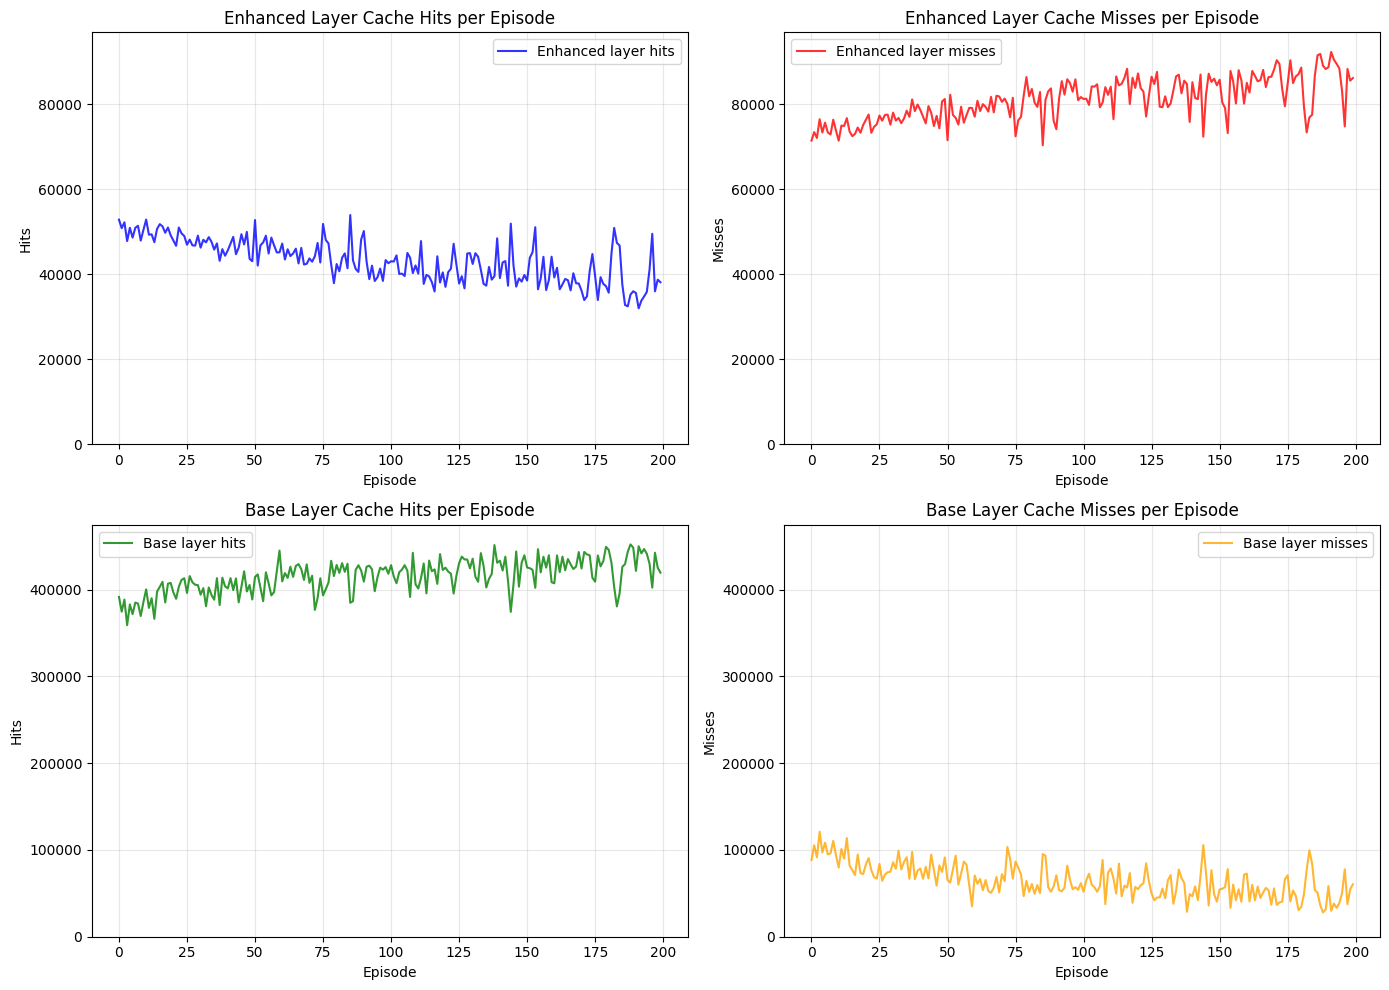

In [16]:
from typing import List
import os

def read_results(csv_path: str):
    episodes: List[int] = []
    enhanced_hits: List[float] = []
    enhanced_misses: List[float] = []
    base_hits: List[float] = []
    base_misses: List[float] = []

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        required_cols = [
            "episode",
            "enhanced_layer_cache_hits",
            "enhanced_layer_cache_misses",
            "base_layer_cache_hits",
            "base_layer_cache_misses",
        ]
        missing = [c for c in required_cols if c not in reader.fieldnames]
        if missing:
            raise ValueError(
                f"CSV missing required columns: {missing}. Found: {reader.fieldnames}"
            )

        for row in reader:
            try:
                episodes.append(int(row["episode"]))
                enhanced_hits.append(float(row["enhanced_layer_cache_hits"]))
                enhanced_misses.append(float(row["enhanced_layer_cache_misses"]))
                base_hits.append(float(row["base_layer_cache_hits"]))
                base_misses.append(float(row["base_layer_cache_misses"]))
            except (ValueError, KeyError):
                # skip malformed rows
                continue

    return episodes, enhanced_hits, enhanced_misses, base_hits, base_misses


def plot_cache_layers(
    csv_path: str,
    out_path: str | None = None,
    title: str | None = None,
):
    episodes, enhanced_hits, enhanced_misses, base_hits, base_misses = read_results(csv_path)

    # Compute shared y-lims per layer type
    def compute_ylim(a, b, pad=0.05, min_top=1.0):
        top = max(max(a or [0.0]), max(b or [0.0]))
        top = max(min_top, top)
        return (0, top * (1 + pad))

    enh_ylim = compute_ylim(enhanced_hits, enhanced_misses)
    base_ylim = compute_ylim(base_hits, base_misses)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Enhanced Layer Cache Hits
    axes[0, 0].plot(episodes, enhanced_hits, label="Enhanced layer hits", color="blue", alpha=0.8)
    axes[0, 0].set_title("Enhanced Layer Cache Hits per Episode")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Hits")
    axes[0, 0].set_ylim(enh_ylim)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Plot 2: Enhanced Layer Cache Misses
    axes[0, 1].plot(episodes, enhanced_misses, label="Enhanced layer misses", color="red", alpha=0.8)
    axes[0, 1].set_title("Enhanced Layer Cache Misses per Episode")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Misses")
    axes[0, 1].set_ylim(enh_ylim)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Plot 3: Base Layer Cache Hits
    axes[1, 0].plot(episodes, base_hits, label="Base layer hits", color="green", alpha=0.8)
    axes[1, 0].set_title("Base Layer Cache Hits per Episode")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Hits")
    axes[1, 0].set_ylim(base_ylim)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Plot 4: Base Layer Cache Misses
    axes[1, 1].plot(episodes, base_misses, label="Base layer misses", color="orange", alpha=0.8)
    axes[1, 1].set_title("Base Layer Cache Misses per Episode")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("Misses")
    axes[1, 1].set_ylim(base_ylim)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    csv_filepath = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U500_V1000_G60_L2_N4_cap100MB_eps0.05_2.csv'
    
    out_path = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U500_V1000_G60_L2_N4_cap100MB_eps0.05_2_layers.png'

    title = "FOV Predictor DQN Agent Cache Layers Performance"

    plot_cache_layers(
        csv_filepath, 
        out_path=None, 
        title=title
    )


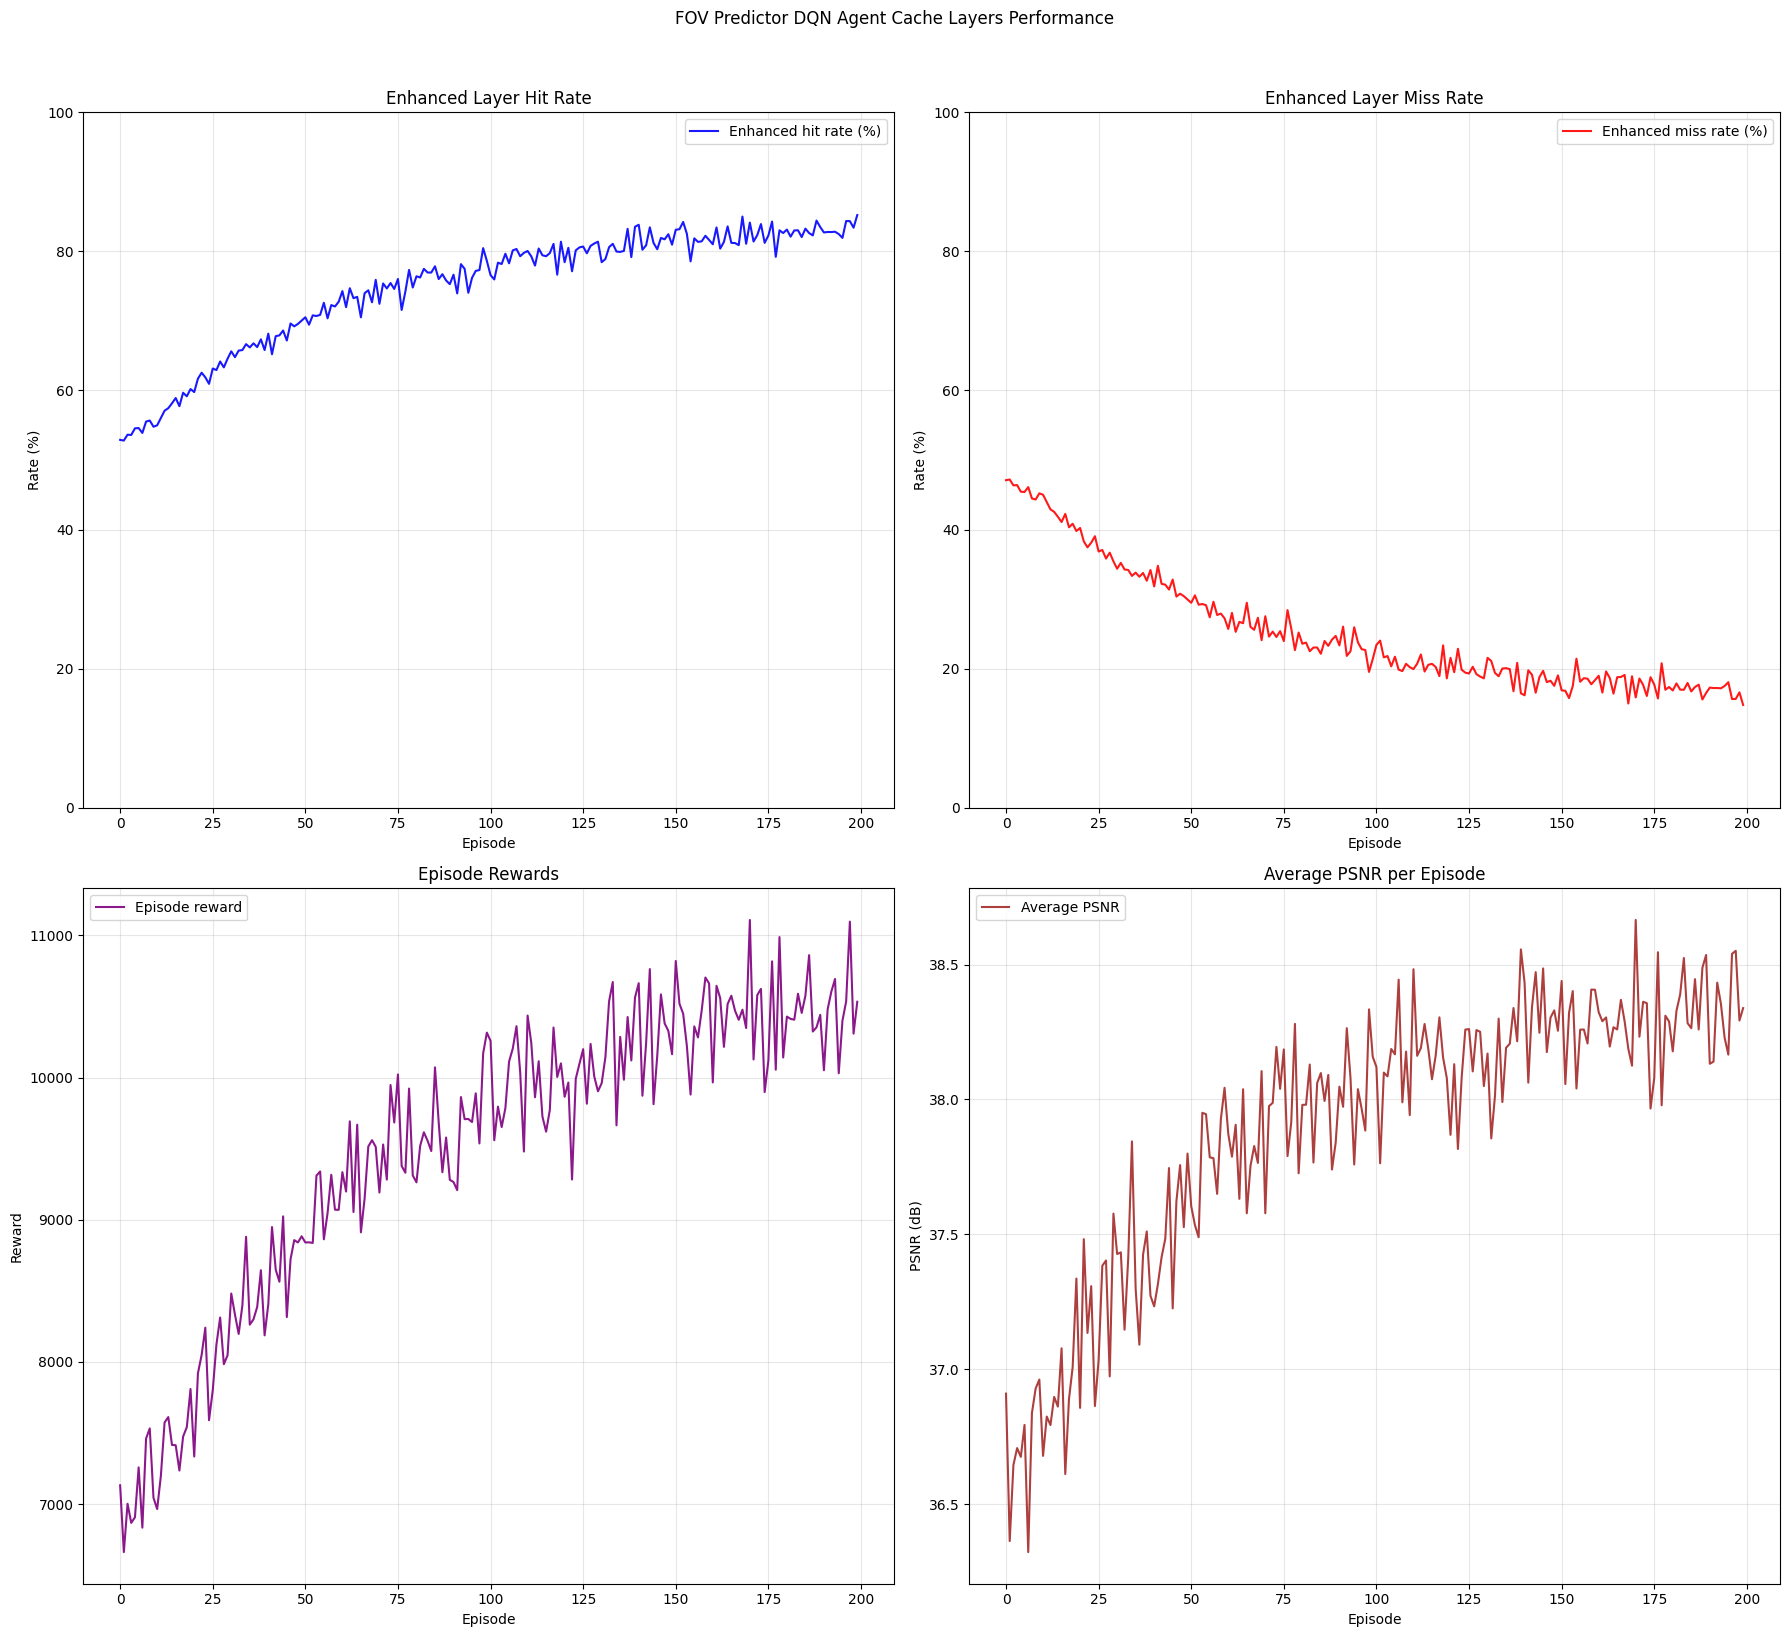

In [17]:
from typing import List
import os

def read_results(csv_path: str):
    episodes: List[int] = []
    enhanced_hits: List[float] = []
    enhanced_misses: List[float] = []
    base_hits: List[float] = []
    base_misses: List[float] = []
    rewards: List[float] = []
    avg_psnr: List[float] = []

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        required_cols = [
            "episode",
            "enhanced_layer_cache_hits",
            "enhanced_layer_cache_misses",
            "base_layer_cache_hits",
            "base_layer_cache_misses",
            "total_reward",
            "average_psnr"
        ]
        
        missing = [c for c in required_cols if c not in reader.fieldnames]
        if missing:
            raise ValueError(
                f"CSV missing required columns: {missing}. Found: {reader.fieldnames}"
            )

        for row in reader:
            try:
                episodes.append(int(row["episode"]))
                enhanced_hits.append(float(row["enhanced_layer_cache_hits"]))
                enhanced_misses.append(float(row["enhanced_layer_cache_misses"]))
                base_hits.append(float(row["base_layer_cache_hits"]))
                base_misses.append(float(row["base_layer_cache_misses"]))
                rewards.append(float(row["total_reward"]))
                avg_psnr.append(float(row["average_psnr"]))
            except (ValueError, KeyError):
                # skip malformed rows
                continue

    return episodes, enhanced_hits, enhanced_misses, base_hits, base_misses, rewards, avg_psnr


def plot_cache_layers(
    csv_path: str,
    out_path: str | None = None,
    title: str | None = None,
):
    episodes, enhanced_hits, enhanced_misses, base_hits, base_misses, rewards, psnr = read_results(csv_path)

    # Compute per-episode percentages
    def safe_pct(num, den):
        return 0.0 if den == 0 else 100.0 * num / den

    enh_totals = [h + m for h, m in zip(enhanced_hits, enhanced_misses)]

    enh_hit_rate = [safe_pct(h, t) for h, t in zip(enhanced_hits, enh_totals)]
    enh_miss_rate = [safe_pct(m, t) for m, t in zip(enhanced_misses, enh_totals)]

    # Shared y-lims per layer type (percentages)
    enh_ylim = (0, 100)

    fig, axes = plt.subplots(2, 2, figsize=(18, 16))

    # Enhanced Layer: Hit rate
    axes[0, 0].plot(episodes, enh_hit_rate, label="Enhanced hit rate (%)", color="blue", alpha=0.9)
    axes[0, 0].set_title("Enhanced Layer Hit Rate")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Rate (%)")
    axes[0, 0].set_ylim(enh_ylim)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Enhanced Layer: Miss rate
    axes[0, 1].plot(episodes, enh_miss_rate, label="Enhanced miss rate (%)", color="red", alpha=0.9)
    axes[0, 1].set_title("Enhanced Layer Miss Rate")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Rate (%)")
    axes[0, 1].set_ylim(enh_ylim)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Reward title
    axes[1, 0].plot(episodes, rewards, label="Episode reward", color="purple", alpha=0.9)
    axes[1, 0].set_title("Episode Rewards")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Reward")
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Average PSNR
    axes[1, 1].plot(episodes, psnr, label="Average PSNR", color="brown", alpha=0.9)
    axes[1, 1].set_title("Average PSNR per Episode")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("PSNR (dB)")
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    # csv_filepath = '/home/eduardo/Workspace/CacheVideoPredict360/Results'
    csv_filepath = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results'
    csv_filepath += r'\fov_predictor_U100_V100_G60_L2_N4_cap500MB_AR15.0.csv'
    
    out_path = None

    title = "FOV Predictor DQN Agent Cache Layers Performance"

    plot_cache_layers(
        csv_filepath, 
        out_path=None, 
        title=title
    )

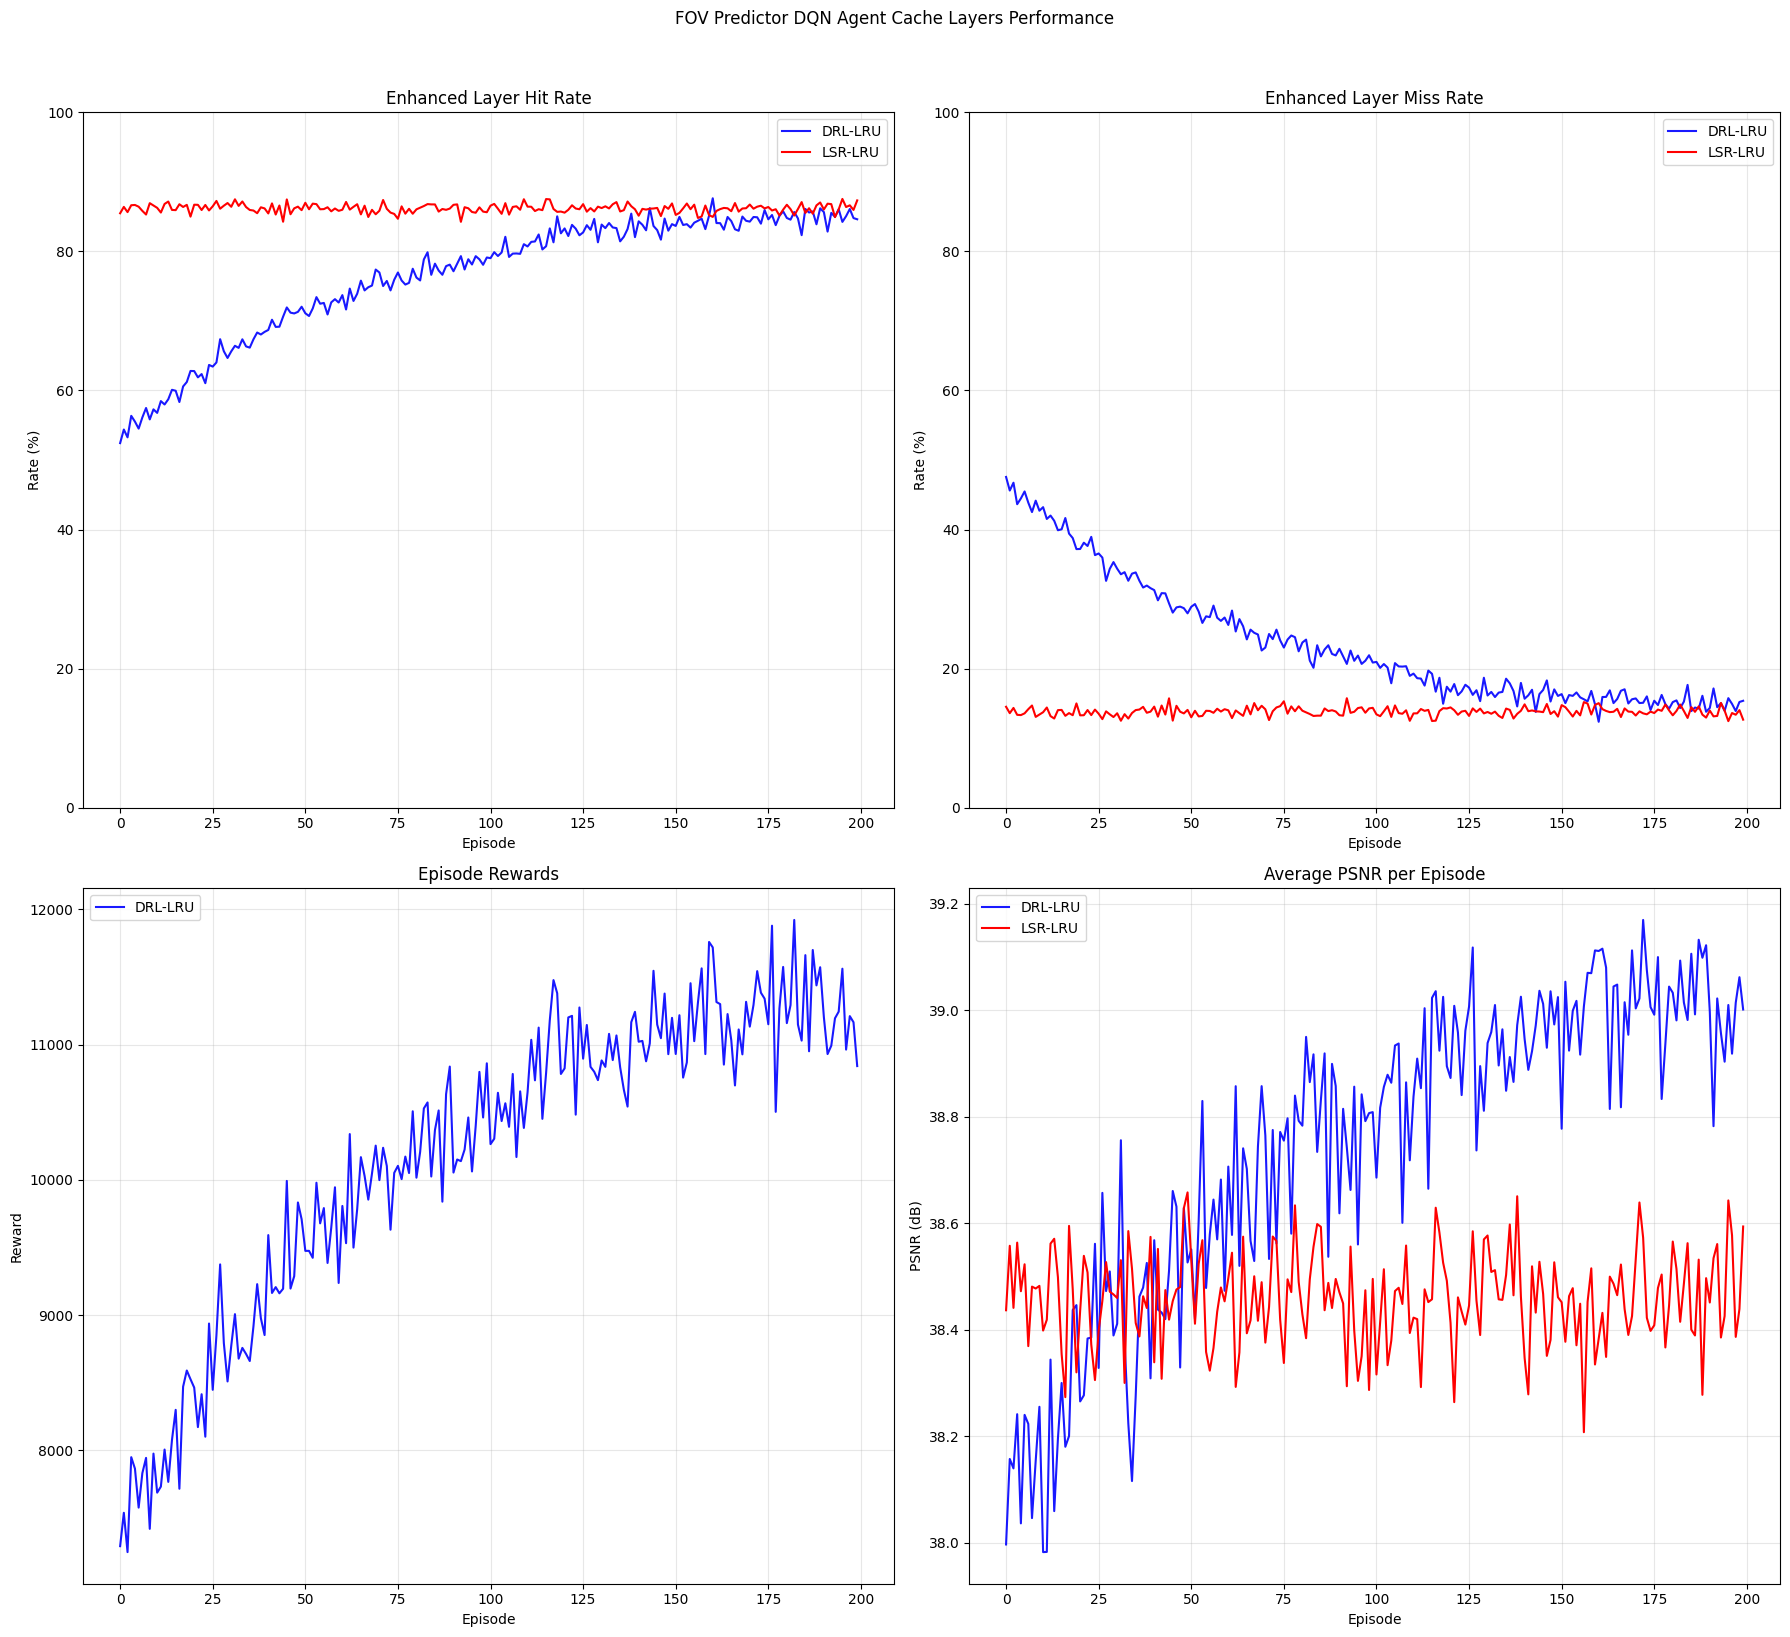

In [ ]:
from typing import List
import os

def read_results(csv_path: str):
    episodes: List[int] = []
    enhanced_hits: List[float] = []
    enhanced_misses: List[float] = []
    base_hits: List[float] = []
    base_misses: List[float] = []
    rewards: List[float] = []
    avg_psnr: List[float] = []

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        required_cols = [
            "episode",
            "enhanced_layer_cache_hits",
            "enhanced_layer_cache_misses",
            "base_layer_cache_hits",
            "base_layer_cache_misses",
            "total_reward",
            "average_psnr"
        ]
        
        missing = [c for c in required_cols if c not in reader.fieldnames]
        if missing:
            raise ValueError(
                f"CSV missing required columns: {missing}. Found: {reader.fieldnames}"
            )

        for row in reader:
            try:
                episodes.append(int(row["episode"]))
                enhanced_hits.append(float(row["enhanced_layer_cache_hits"]))
                enhanced_misses.append(float(row["enhanced_layer_cache_misses"]))
                base_hits.append(float(row["base_layer_cache_hits"]))
                base_misses.append(float(row["base_layer_cache_misses"]))
                rewards.append(float(row["total_reward"]))
                avg_psnr.append(float(row["average_psnr"]))
            except (ValueError, KeyError):
                # skip malformed rows
                continue

    return episodes, enhanced_hits, enhanced_misses, base_hits, base_misses, rewards, avg_psnr


def plot_cache_layers(
    csv_path: str,
    out_path: str | None = None,
    title: str | None = None,
):
    episodes, enhanced_hits, enhanced_misses, base_hits, base_misses, rewards, psnr = read_results(csv_path)

    csv_path_lsr = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results'
    csv_path_lsr += r'\fov_lsr_U100_V100_G60_L2_N4_cap500MB_AR20.csv'

    episodes_lsr, enhanced_hits_lsr, enhanced_misses_lsr, base_hits_lsr, base_misses_lsr, rewards_lsr, psnr_lsr = read_results(csv_path_lsr)

    # Compute per-episode percentages
    def safe_pct(num, den):
        return 0.0 if den == 0 else 100.0 * num / den

    enh_totals = [h + m for h, m in zip(enhanced_hits, enhanced_misses)]

    enh_hit_rate = [safe_pct(h, t) for h, t in zip(enhanced_hits, enh_totals)]
    enh_miss_rate = [safe_pct(m, t) for m, t in zip(enhanced_misses, enh_totals)]

    # Shared y-lims per layer type (percentages)
    enh_ylim = (0, 100)

    fig, axes = plt.subplots(2, 2, figsize=(18, 16))

    # Enhanced Layer: Hit rate
    axes[0, 0].plot(episodes, enh_hit_rate, label="DRL-LRU", color="blue", alpha=0.9)
    axes[0, 0].plot(episodes_lsr, [safe_pct(h, h + m) for h, m in zip(enhanced_hits_lsr, enhanced_misses_lsr)], label="LSR-LRU", color="red")
    axes[0, 0].set_title("Enhanced Layer Hit Rate")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Rate (%)")
    axes[0, 0].set_ylim(enh_ylim)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Enhanced Layer: Miss rate
    axes[0, 1].plot(episodes, enh_miss_rate, label="DRL-LRU", color="blue", alpha=0.9)
    axes[0, 1].plot(episodes_lsr, [safe_pct(m, h + m) for h, m in zip(enhanced_hits_lsr, enhanced_misses_lsr)], label="LSR-LRU", color="red")
    axes[0, 1].set_title("Enhanced Layer Miss Rate")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Rate (%)")
    axes[0, 1].set_ylim(enh_ylim)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Reward title
    axes[1, 0].plot(episodes, rewards, label="DRL-LRU", color="blue", alpha=0.9)
    axes[1, 0].set_title("Episode Rewards")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Reward")
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Average PSNR
    axes[1, 1].plot(episodes, psnr, label="DRL-LRU", color="blue", alpha=0.9)
    axes[1, 1].plot(episodes_lsr, psnr_lsr, label="LSR-LRU", color="red")
    axes[1, 1].set_title("Average PSNR per Episode")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("PSNR (dB)")
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    # csv_filepath = '/home/eduardo/Workspace/CacheVideoPredict360/Results'
    csv_filepath = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results'
    csv_filepath += r'\fov_predictor_U100_V100_G60_L2_N4_cap500MB_AR15.csv'
    
    out_path = None

    title = "FOV Predictor DQN Agent Cache Layers Performance"

    plot_cache_layers(
        csv_filepath, 
        out_path=None, 
        title=title
    )